In [1]:
!pip install matplotlib

In [2]:
import matplotlib as mpl

In [3]:
!pip install qiskit qiskit-aer qiskit-ibm-runtime

In [4]:
import qiskit
from qiskit import QuantumCircuit #quantumcircuit is a class with two parameters (number of qubits,number of qubits we want to observe or measure)

In [66]:
circuit=QuantumCircuit(4,2)

In [6]:
!pip install pylatexenc

In [7]:
import pylatexenc

In [ ]:
#x is a function for paulixgate

In [59]:
#circuit.x(0)
#circuit.x(1)
#circuit.x(0)
#circuit.x(1)

In [67]:
circuit.x(0)

In [68]:
#to isolate the circuit from the input we use the barrier
circuit.barrier()

CircuitInstruction(operation=Instruction(name='barrier', num_qubits=4, num_clbits=0, params=[]), qubits=(Qubit(QuantumRegister(4, 'q'), 0), Qubit(QuantumRegister(4, 'q'), 1), Qubit(QuantumRegister(4, 'q'), 2), Qubit(QuantumRegister(4, 'q'), 3)), clbits=())

In [69]:
circuit.cx(0,2)
circuit.cx(1,2)
circuit.ccx(0,1,3)
#for cx gate two input index of control qubit and index of target qubit
#circuit.x(2)#i is the qubit to which we are applying the paulixgate

In [70]:
circuit.measure(2,0)
circuit.measure(3,1)
#circuit.measure(1,1)

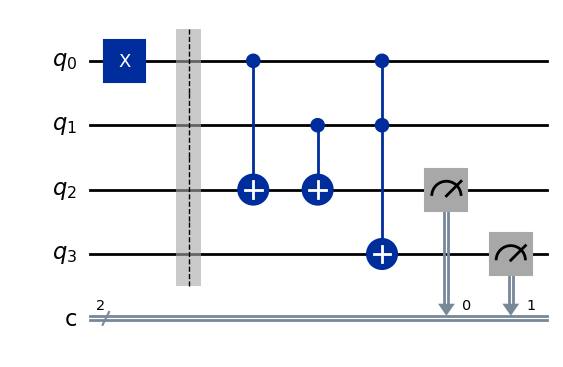

In [71]:
circuit.draw("mpl")

In [72]:
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

backend= Aer.get_backend('qasm_simulator')
job=backend.run(circuit)
counts=job.result().get_counts()

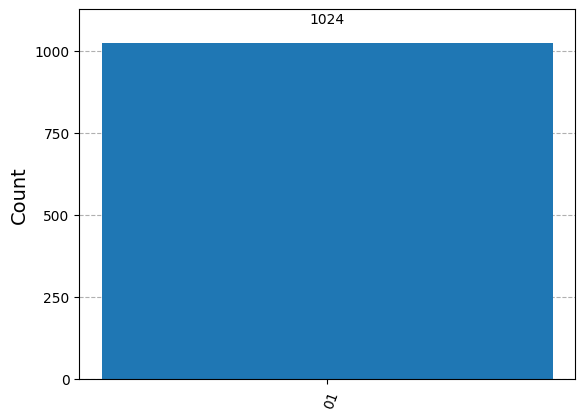

In [73]:
plot_histogram(counts)

In [74]:
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService(
    channel='ibm_quantum',
    instance='ibm-q/open/main',
    token='000621b6360b60f773d477c567e3c8401fec7d969d5af509a9a8671c5e64bb187ff9837ae800279fbc249579593a4544db561fd8cb881fc22d477ff92abb112e'
)

# Or save your credentials on disk.
# QiskitRuntimeService.save_account(channel='ibm_quantum', instance='ibm-q/open/main', token='000621b6360b60f773d477c567e3c8401fec7d969d5af509a9a8671c5e64bb187ff9837ae800279fbc249579593a4544db561fd8cb881fc22d477ff92abb112e')

In [75]:
from qiskit_ibm_runtime import Sampler

In [76]:
backend=service.least_busy(simulator=False,operational=True)#least busy provides us with the less traffic qpu

In [77]:
sampler= Sampler(mode=backend)

In [78]:
backend

<IBMBackend('ibm_brisbane')>

In [79]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager #it has different functions for different backend
pm=generate_preset_pass_manager(backend=backend,optimization_level=0)#here we use the backedn we are using

In [80]:
transpiled_circuit=pm.run(circuit)#transpilation converting the circuit that the qpu backend understands

In [82]:
transpiled_circuit.draw("mpl")

Output hidden; open in https://colab.research.google.com to view.

In [88]:
job=sampler.run([(transpiled_circuit)],shots=1024)

In [89]:
job.job_id()

'cy20p0r6vek0008rbqf0'

In [90]:
job.status()

'QUEUED'

In [91]:
counts_real=job.result()[0].data.c.get_counts()

KeyboardInterrupt: 

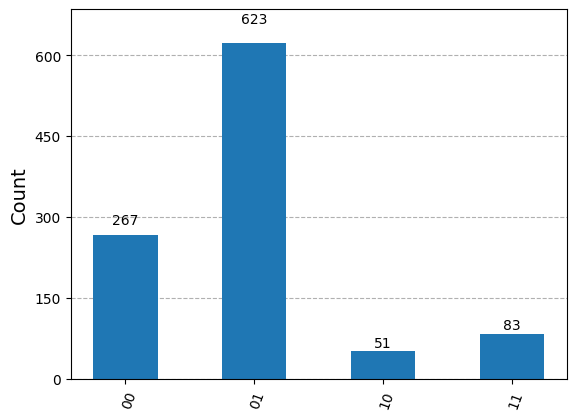

In [87]:
plot_histogram(counts_real)